# Thinking in $\sigma$-algebras: An information-theoretic introduction to SigAlg

[SigAlg](https://johnmyers-phd.com/sigalg/) is a Python library for mathematical probability theory. While the more elementary parts of this subject are adequately covered in numerous sources, the more advanced sections are usually reserved for textbooks that are pitched at the advanced undergraduate and graduate levels. Indeed, a complete and rigorous treatment of modern probability theory requires considerable background knowledge and preparation. However, if one restricts their attention to discrete probability (as we do in SigAlg), then all those intricate measure-theoretic structures in the advanced textbooks are rendered pleasingly concrete and tangible. In particular, the *$\sigma$-algebras* over a finite sample space — those fundamental objects that carry and encode "information" — are equivalent to partitions of the sample space, and there is nothing more concrete than a partition of a finite set. If the reader has internalized the ideas behind the familiar *Law of Total Probability* over finite partitions, then they've already learned how to think in terms of $\sigma$-algebras.

This notebook is a further introduction to thinking and reasoning with these structures. We focus on a single problem, a toy example that asks us to identify a ball of different weight out of a collection of otherwise identically weighted balls using a balance scale. This example is used to great effect in David MacKay's textbook [Information Theory, Inference, and Learning Algorithms](http://www.inference.org.uk/itprnn/book.pdf) to introduce and motivate the idea of *Shannon information content*, and while there is little room for improvement on MacKay's excellent exposition, our goal is to reframe the discussion in terms of $\sigma$-algebras, demonstrating that these objects are the ideal structures to model evolving "information". The reader will also encounter *filtrations* of $\sigma$-algebras, which are some of the central structures in probabilistic models used in mathematical finance, among other areas. And, of course, all this will be demonstrated with SigAlg code.

In [1]:
# If running in Google Colab, uncomment the line below and run this cell first.
# Also, for Mac+Chrome users, beware of a known bug with LaTeX redering in Colab: https://github.com/googlecolab/colabtools/issues/3192

# !pip install sigalg

## The problem statement

The situation is this. You are given twelve balls, all the same weight except one, which is either heavier or lighter than the other eleven. Given a balance scale (the old-fashioned kind, with two pans), your goal is to describe a strategy that identifies the odd ball out of the twelve, whether it is heavier or lighter, and to do so in *as few uses of the scale as possible.*

For example, we might initially believe that the optimal first weighing is to put six balls in each of the two pans of the scale. It is then guaranteed that one pan will be heavier than the other — but is that because the heavier pan contains the odd ball which is *heavier* than the rest, or because the lighter pan contains the odd ball which is *lighter*? Remember, the strategy must not only reveal the odd ball, but also which way it tips the balance.

Before continuing, take a moment to ponder a few candidate strategies.

## Enter $\sigma$-algebras

The purpose and use of the balance scale in the problem is as a mechanism to obtain *information*. Each weighing — however many your strategy requires — affords you new information, and your overarching goal is to arrange your strategy so as to *maximize* the information gain at each weighing. So, unless you found a strategy that uses a single weighing (in which case I suggest you submit your strategy to closer scrutiny), this is really a problem about information *evolution*. While one can identify and establish optimality of the ideal solution using plain language (just as MacKay does), it turns out that *$\sigma$-algebras* and their *filtrations* are practically purpose-built for encoding information evolution. Let's see how they work.

First, we begin with a sample space. There are $24 = 12 \times 2$ possibilities for the outcome of your strategy, since there are twelve balls and two possibilities for the weight of the odd one compared to the rest (i.e., heavier vs. lighter). This suggests that the outcomes of your strategy lie in the sample space

$$
\Omega = \{1^+,2^+,3^+,\ldots,12^+,1^-,2^-,3^-,\ldots,12^-\},
$$

where the number in the "base" of $\omega \in \Omega$ represents the identity of the odd ball and the "exponent" codes whether it is heavier ($+$) or lighter ($-$). There is nothing in the statement of the problem that indicates any one of these outcomes is more likely to occur than any another, so a uniform probability measure $P$ is assigned to the sample space $\Omega$ with $P(A) = |A|/24$, for any event $A\subset\Omega$ (where $|A|$ denotes the cardinality of $A$).

Let's program these structures in SigAlg, beginning with the sample space.

In [2]:
import sigalg as sa

Omega = sa.SampleSpace(
    [f"{k}+" for k in range(1, 13)] + [f"{k}-" for k in range(1, 13)]
)
print(Omega)

Sample space 'Omega':
omega
   1+
   2+
   3+
   4+
   5+
   6+
   7+
   8+
   9+
  10+
  11+
  12+
   1-
   2-
   3-
   4-
   5-
   6-
   7-
   8-
   9-
  10-
  11-
  12-


Then, we code the (uniform) probability measure, constructed using the `uniform` class method of the `ProbabilityMeasure` class.

In [3]:
P = sa.ProbabilityMeasure.uniform(domain=Omega, name="P")
print(P)

Probability measure 'P':
              P
omega          
1+     0.041667
2+     0.041667
3+     0.041667
4+     0.041667
5+     0.041667
6+     0.041667
7+     0.041667
8+     0.041667
9+     0.041667
10+    0.041667
11+    0.041667
12+    0.041667
1-     0.041667
2-     0.041667
3-     0.041667
4-     0.041667
5-     0.041667
6-     0.041667
7-     0.041667
8-     0.041667
9-     0.041667
10-    0.041667
11-    0.041667
12-    0.041667


Now, think about the first weighing in your candidate strategy. Suppose, for example, that it is the naive one described in the problem statement, where you place six balls in each of the two pans of the balance: Balls $1$ through $6$ go in the left pan, and balls $7$ through $12$ in the right. Then either the left pan is heavier, which means that the event

$$
C_0 = \{1^+,2^+,3^+,4^+,5^+,6^+,7^-,8^-,9^-,10^-,11^-,12^-\}
$$

occurs, or the right pan is heavier and the event

$$
C_1 = \{1^-,2^-,3^-,4^-,5^-,6^-,7^+,8^+,9^+,10^+,11^+,12^+\}
$$

occurs. The key structure to notice is that $C_0$ and $C_1$ are disjoint events (no outcomes in common) and their union is all of $\Omega$. In mathematical terms, this means that these two events form a *partition* of $\Omega$.

Folks, you have just experienced your first encounter with a $\sigma$-algebra. Indeed, formally a *$\sigma$-algebra* on $\Omega$ is a collection $\mathcal{F}$ of subsets of $\Omega$ that satisfies certain axioms whose precise elucidations aren't important to us now, but in the case that $\Omega$ is finite, the key result is that $\sigma$-algebras on $\Omega$ are in one-to-one correspondence with partitions of $\Omega$ like the one above. Let's use $\mathcal{G}_1$ to stand for the $\sigma$-algebra associated with $C_0$ and $C_1$ under this correspondence — the latter two sets are then called the *atoms* of $\mathcal{G}_1$.

Let's program $\mathcal{G}_1$ in SigAlg. To do so, we define a dictionary that maps each sample point $\omega$ to the subscript $i$ for which $\omega \in C_i$, and pass this dictionary into the `mapping` parameter of the `SigmaAlgebra` constructor.

In [4]:
C0 = dict.fromkeys([f"{k}+" for k in range(1, 7)] + [f"{k}-" for k in range(7, 13)], 0)
C1 = dict.fromkeys([f"{k}-" for k in range(1, 7)] + [f"{k}+" for k in range(7, 13)], 1)

G1 = sa.SigmaAlgebra(domain=Omega, mapping=C0 | C1, name="G1")
print(G1)

Sigma algebra 'G1':
       G1
omega    
1+      0
2+      0
3+      0
4+      0
5+      0
6+      0
7+      1
8+      1
9+      1
10+     1
11+     1
12+     1
1-      1
2-      1
3-      1
4-      1
5-      1
6-      1
7-      0
8-      0
9-      0
10-     0
11-     0
12-     0


The probability measure $P$ is uniform, and both atoms $C_0$ and $C_1$ contain $12$ out of the $24$ total sample points, so they both have probability $1/2$. We may verify this in SigAlg, while also demonstrating that objects of the `SigmaAlgebra` class may be "unpacked" into their atoms.

In [5]:
C0, C1 = G1

print(P(C0))
print(P(C1))

0.5
0.5


## A deficiency in the naive strategy

The clever reader might already have realized *why* we have referred to the strategy that begins with six balls in each pan as naive: We are not using the scale to its full potential. For not only can the scale tell us if one pan weighs more than the other, it can also tell us whether the two pans are equal in weight. There are thus three possible sources of information resulting from a weighing, but the naive strategy only uses two of them and effectively closes off the third.

So, a better first weighing leverages all three possible readings from the scale. Such a weighing must necessarily hold out some of the balls. Suppose that balls $1$-$4$ go in the left pan, balls $5$-$8$ go in the right, and the remaining balls $9$-$12$ are held out. If the left pan is heavier than the right, then the event

$$
A_0 = \{1^+,2^+,3^+,4^+,5^-,6^-,7^-,8^-\},
$$

occurs, while if the right pan is heavier the event

$$
A_1 = \{1^-,2^-,3^-,4^-,5^+,6^+,7^+,8^+\},
$$

occurs, and finally if the pans balance then the event

$$
A_2 = \{9^+,10^+,11^+,12^+,9^-,10^-,11^-,12^-\}
$$

occurs. Again, notice that the $A$'s partition the sample space $\Omega$, and so they form the atoms of a $\sigma$-algebra that we shall call $\mathcal{F}_1$.

Let's define $\mathcal{F}_1$ in SigAlg.

In [6]:
A0 = dict.fromkeys([f"{k}+" for k in range(1, 5)] + [f"{k}-" for k in range(5, 9)], 0)
A1 = dict.fromkeys([f"{k}-" for k in range(1, 5)] + [f"{k}+" for k in range(5, 9)], 1)
A2 = dict.fromkeys([f"{k}+" for k in range(9, 13)] + [f"{k}-" for k in range(9, 13)], 2)

F1 = sa.SigmaAlgebra(domain=Omega, mapping=A0 | A1 | A2, name="F1")
print(F1)

Sigma algebra 'F1':
       F1
omega    
1+      0
2+      0
3+      0
4+      0
5+      1
6+      1
7+      1
8+      1
9+      2
10+     2
11+     2
12+     2
1-      1
2-      1
3-      1
4-      1
5-      0
6-      0
7-      0
8-      0
9-      2
10-     2
11-     2
12-     2


## The optimal strategy

But not only does this new first weighing leverage all three possible readings of the scale, it appears to be optimal in another sense, as well. To explain, notice that the probabilities of the atoms are all identical:

$$
P(A_0) = P(A_1) = P(A_2) = \frac{1}{3}.
$$

If this were *not* the case, for example if we held out only the two balls $11$ and $12$ and evenly divided the remaining ten between the two pans as above, then we would instead have the probabilities

$$
P(A_0) = P(A_1) =  \frac{5}{12}, \quad P(A_2) = \frac{1}{6}.
$$

In this latter case, even before we weigh the balls, we know it is more likely that one of the events $A_1$ or $A_2$ occurs — but we then wouldn't be too surprised if one of these two events *actually* occurred, would we? If we use our level of "surprise" as a proxy for the amount of information conveyed by a weighing, then this arrangement with unequal probabilties gives us less information than the one with equal probabilities.

Not convinced? Take the extreme example where we load all twelve balls into the left pan on the first weighing. Then the result of the weighing is a single event that is *certain* to occur. But the absence of surprise (i.e., certainty) means no information has been obtained.

This is all horribly vague, of course, and one of the goals of information theory is to turn it into precise mathematics. *But to conclude: The optimal strategy must, first of all, leverage all three outcomes of the scale: "left heavier", "right heavier", and "equal weight". Then, at each weighing, the strategy must be arranged so that these three events are as near equiprobable as possible in order to maximize information gain.*

With this goal in mind, do you still believe that your candidate strategy — whatever it is — is still the optimal one? The true optimal strategy, straight from MacKay's book, is given in a lovely diagram at [this](https://github.com/jmyers7/sigalg/blob/60c62b6bdaf63b611f638dcd7c2d9b52c31ba03f/docs/notebooks/files/weighings.pdf) link. Please take a moment to study this diagram before continuing.

## Enter filtrations of $\sigma$-algebras

Notice the node at the far left of MacKay's diagram is the entire sample space $\Omega$. Reading from left to right, the first weighing partitions the sample space into the three atoms $A_0$, $A_1$, and $A_2$ of the $\sigma$-algebra $\mathcal{F}_1$ described above. Then, the second weighing partitions each of these three atoms into three subsets, that we will label according to the nodes in the following diagram (which you should imagine is superimposed on MacKay's).

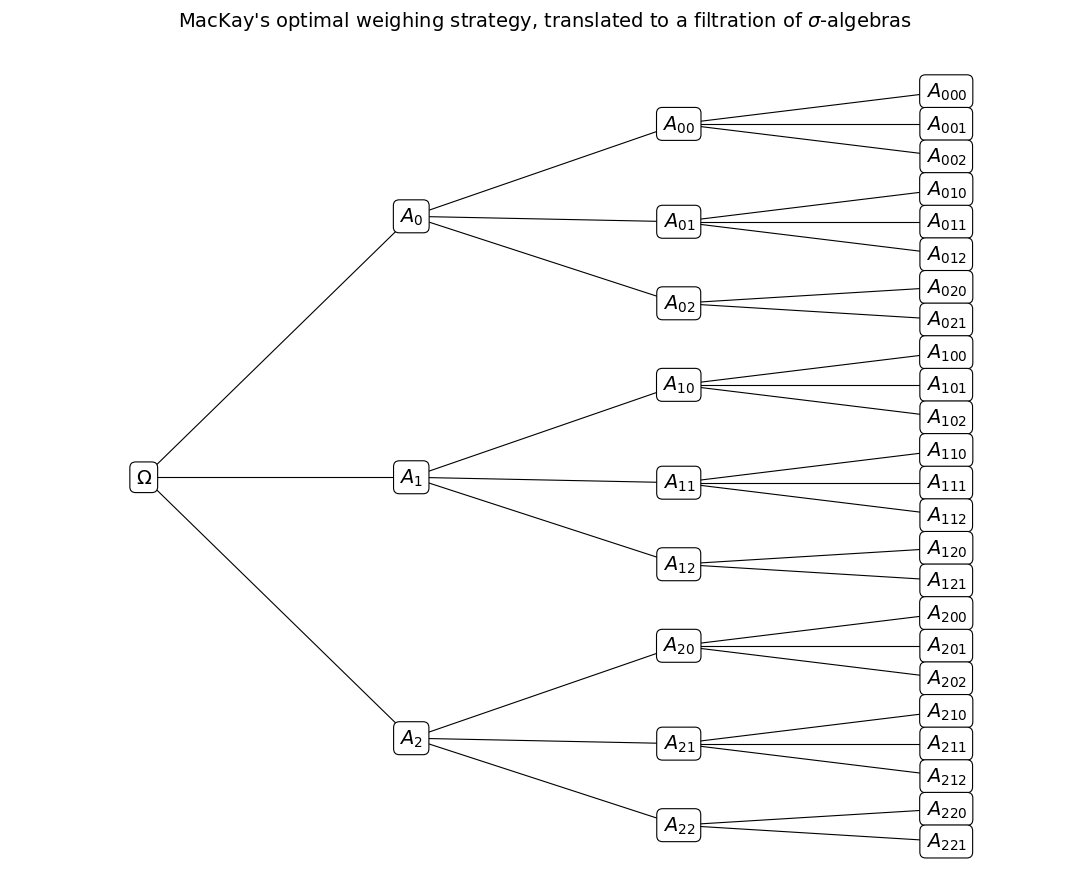

In [7]:
from sigalg._docs_utils import plot_intro_notebook_filtration

plot_intro_notebook_filtration()

These nine events $A_{00}, A_{01}, \ldots, A_{22}$ form the atoms of a second $\sigma$-algebra that we shall call $\mathcal{F}_2$.  Finally, the third (and final) weighing in MacKay's optimal strategy partitions six of nine atoms of $\mathcal{F}_2$ into three subsets, and three atoms into two subsets. Together, these $24$ subsets form the atoms of a third $\sigma$-algebra that we shall call $\mathcal{F}_3$.

If we define $\mathcal{F}_0$ to be the $\sigma$-algebra on $\Omega$ whose only atom is $\Omega$ itself, then we have four $\sigma$-algebras at hand, $\mathcal{F}_0$, $\mathcal{F}_1$, $\mathcal{F}_2$ and $\mathcal{F}_3$, each corresponding to a level in the ternary tree above. Each $\sigma$-algebra is a *refinement* of the preceding one, in the sense that each atom of $\mathcal{F}_{k+1}$ is contained in a unique atom of $\mathcal{F}_{k}$, for each of $k=0,1,2$. (Equivalently: Each atom of $\mathcal{F}_k$ is a union of atoms of $\mathcal{F}_{k+1}$.) Under the correspondence between $\sigma$-algebras and atomic partitions mentioned above, this refinement structure translates to a chain

$$
\mathcal{F}_0 \subset \mathcal{F}_1 \subset \mathcal{F}_2 \subset \mathcal{F}_3
$$

of subset inclusions of $\sigma$-algebras. Such a chain is called a *filtration* of $\sigma$-algebras. Moving through the filtration, the reader should imagine a progression and accumulation of ever finer information, from the most coarse-grained information in $\mathcal{F}_0$ (one of the balls is odd), to the most fine-grained in $\mathcal{F}_3$ (the exact identity of the odd ball and its relative weight compared to the others).

This viewpoint makes it obvious that MacKay's strategy really is the optimal one, for any successful strategy must produce a filtration of $\sigma$-algebras (i.e., an evolution of information) that terminates in the $\sigma$-algebra $\mathcal{F}_3$ with its $24$ singleton atoms. But we cannot reach this $\sigma$-algebra in two weighings, because each atom can only split into a maximum of three subsets, and so two weighings produces a terminal $\sigma$-algebra with $\leq 9$ atoms. So, the optimal strategy *cannot* consist of only two weighings, but it *can* be done in three, as MacKay demonstrates; therefore, his strategy is optimal.

## The `Filtration` class

SigAlg contains a `Filtration` class built as a convenient container for filtrations of $\sigma$-algebras. We demonstrate its basic usage in this section before proceeding.

First, we program the $\sigma$-algebra $\mathcal{F}_2$.

In [8]:
A00 = dict.fromkeys(["1+", "2+", "5-"], "00")
A01 = dict.fromkeys(["3+", "4+", "6-"], "01")
A02 = dict.fromkeys(["7-", "8-"], "02")
A10 = dict.fromkeys(["6+", "3-", "4-"], "10")
A11 = dict.fromkeys(["1-", "2-", "5+"], "11")
A12 = dict.fromkeys(["7+", "8+"], "12")
A20 = dict.fromkeys(["9+", "10+", "11+"], "20")
A21 = dict.fromkeys(["9-", "10-", "11-"], "21")
A22 = dict.fromkeys(["12+", "12-"], "22")

F2 = sa.SigmaAlgebra(
    domain=Omega, mapping=A00 | A01 | A02 | A10 | A11 | A12 | A20 | A21 | A22, name="F2"
)
print(F2)

Sigma algebra 'F2':
       F2
omega    
1+     00
2+     00
3+     01
4+     01
5+     11
6+     10
7+     12
8+     12
9+     20
10+    20
11+    20
12+    22
1-     11
2-     11
3-     10
4-     10
5-     00
6-     01
7-     02
8-     02
9-     21
10-    21
11-    21
12-    22


Then, we program the $\sigma$-algebra $\mathcal{F}_0$, whose only atom is the sample space itself. This is an example of a *trivial* $\sigma$-algebra, which may be coded using the `trivial` class method of the `SigmaAlgebra` class.

In [9]:
F0 = sa.SigmaAlgebra.trivial(domain=Omega, name="F0")
print(F0)

Sigma algebra 'F0':
       F0
omega    
1+      0
2+      0
3+      0
4+      0
5+      0
6+      0
7+      0
8+      0
9+      0
10+     0
11+     0
12+     0
1-      0
2-      0
3-      0
4-      0
5-      0
6-      0
7-      0
8-      0
9-      0
10-     0
11-     0
12-     0


Notice the default atom index in SigAlg for a trivial $\sigma$-algebra is the integer `0`.

Then, we program the finest $\sigma$-algebra $\mathcal{F}_3$ whose atoms are all singletons of the sample space. This is an example of a *power-set $\sigma$-algebra*, which may be built using the `power_set` class method.

In [10]:
F3 = sa.SigmaAlgebra.power_set(domain=Omega, name="F3")
print(F3)

Sigma algebra 'F3':
        F3
omega     
1+      1+
2+      2+
3+      3+
4+      4+
5+      5+
6+      6+
7+      7+
8+      8+
9+      9+
10+    10+
11+    11+
12+    12+
1-      1-
2-      2-
3-      3-
4-      4-
5-      5-
6-      6-
7-      7-
8-      8-
9-      9-
10-    10-
11-    11-
12-    12-


The default atom identifiers for a power-set $\sigma$-algebra in SigAlg are the sample points themselves.

Now, we pass all four of our $\sigma$-algebras (in order) into the `Filtration` constructor.

In [11]:
F = sa.Filtration(sig_algs=[F0, F1, F2, F3])
F

Filtration(name='F', length=4)

Instances of `Filtration` in SigAlg are subscriptable. For example, the $\sigma$-algebra $\mathcal{F}_1$ is obtainable via the following:

In [12]:
F[1]

SigmaAlgebra(domain=Omega, num_atoms=3, variable_names=['F1'], name=F_1)

## Measuring information

The simple proof given above for the optimality of MacKay's weighing strategy is based on a structural constraint: Since the scale can only tell us one of three things, each atom of a $\sigma$-algebra in the filtration can only split into a maximum of three sub-atoms of the next $\sigma$-algebra. However, this *structural* constraint may be translated into a *numerical* constraint that gives an upper bound on the rate at which information is accumulated per step in the filtration.

To explain, let's first note that the probability space in question is $(\Omega, \mathcal{F}_3, P)$, where $\mathcal{F}_3$ is the power-set $\sigma$-algebra. Generally, if $\mathcal{G}$ is a sub-$\sigma$-algebra of $\mathcal{F}_3$, then its *entropy* is defined to be the quantity

$$
H(\mathcal{G}) = - \sum_{B} \log_3{\left(P(B) \right)} P(B),
$$

where the sum is extended over all atoms of $\mathcal{G}$ and we take the base-$3$ logarithm. (This choice of base makes some of the numbers work out nicely in our current context, but any base will do just as well.) In information theory, one interpretation of the entropy is as a measure of the "uncertainty" present in the $\sigma$-algebra, but it is also often conceptualized as the average amount of (*Shannon*) *information* in the $\sigma$-algebra. The entropy is therefore maximized when uncertainty is maximized, i.e., for $\sigma$-algebras in which each atom is equiprobable; in this case, the entropy is the logarithm of the number of atoms. So, since $P$ is uniform and $\mathcal{F}_3$ consists of singletons, the entropy $H(\mathcal{F}_3)$ should be equal to $\log_3{24}$, which we may verify in SigAlg using the `entropy` method of a `SigmaAlgebra` object.

In [13]:
import numpy as np

bool(F[3].entropy(measure=P, base=3) == np.log(24) / np.log(3))

True

At the other end of the spectrum, entropy is minimized when uncertainty is minimized, i.e., for $\sigma$-algebras that have one atom of probability $1$. An example would be the initial $\sigma$-algebra $\mathcal{F}_0$ in our filtration, the trivial $\sigma$-algebra that contains *no* information.

In [14]:
F[0].entropy(measure=P, base=3)

0.0

We interpret $H(\mathcal{F}_3) = \log_3{24} \approx 2.89$ as the total amount of information needed to specify the identity of the odd ball and whether it is heavier or lighter; we interpret $H(\mathcal{F}_0) =0$ as the total amount of information that we begin with (none). Each weighing represents an addition of information that increases our accumulated amount progressively from $0$ to $\log_3{24}\approx 2.89$, and we then ask: What is the maximum amount of information that may be obtained in one weighing? And how do we make this idea of "accumulation" precise?

The answer to the second question comes in the form of the *chain rule for entropy*. Applied to the filtration $\mathcal{F}_0 \subset \mathcal{F}_1 \subset \mathcal{F}_2 \subset \mathcal{F}_3$, this gives us the equation

$$
H(\mathcal{F}_3) = H(\mathcal{F}_0) + H(\mathcal{F}_1 \mid \mathcal{F}_0) + H(\mathcal{F}_2 \mid \mathcal{F}_1) + H(\mathcal{F}_3 \mid \mathcal{F}_2). \tag{$\ast$}
$$

The conditional entropies are weighted sums of per-atom entropies; for example, we have

$$
H(\mathcal{F}_2 \mid \mathcal{F}_1) = \sum_{A}P(A) H(\mathcal{F}_2 \mid A),
$$

where the sum extends over all atoms of $\mathcal{F}_1$ and $H(\mathcal{F}_2 \mid A)$ is the entropy of $\mathcal{F}_2$ restricted to the atom $A$ equipped with the conditional probability measure. But there are a maximum of three atoms of $\mathcal{F}_2$ contained in any given atom $A$ of $\mathcal{F}_1$, and so we have $H(\mathcal{F}_2 \mid A) \leq \log_3(3) = 1$. Hence $H(\mathcal{F}_2 \mid \mathcal{F}_1) \leq 1$, and similarly for the other conditional entropies. Thus, the answer to the first question posed above is the following: In base $3$, the maximum amount of information obtained at each step in the filtration is $1$ unit.

We may verify the chain rule in our particular case using SigAlg.

In [15]:
F[3].entropy(measure=P, base=3) == F[0].entropy(measure=P, base=3) + sum(
    F[t].entropy(measure=P, given=F[t - 1], base=3) for t in range(1, 4)
)

True

Putting it all together, we see that the right-hand side of the chain rule (equation ($\ast$)) is a sum of terms, each at most $1$, which yields another proof of the optimality of MacKay's weighing strategy, one posed in terms of entropy: Any strategy must ultimately produce an amount of $\log_3{24} \approx 2.89$ of information in order to determine the identity of the odd ball and whether it is heavier or lighter. But since a single weighing can only produce $1$ unit of information (in base 3), any successful strategy must contain at least three weighings. Since MacKay's strategy uses exactly three weighings, it is therefore optimal.

For comparison, recall the first $\sigma$-algebra $\mathcal{G}_1$ that we encountered in our discussion, the one resulting from the first weighing in the "naive" strategy that puts six balls in each of the two pans of the scale. The information obtained from this weighing is:

In [16]:
G1.entropy(measure=P, base=3)

0.6309297535714574

In contrast, the information obtained from the optimal first weighing is maximal, since the atoms of $\mathcal{F}_1$ are all equiprobable:

In [17]:
F1.entropy(measure=P, base=3)

1.0

One might wonder: Even though the weighing that produces $\mathcal{G}_1$ is sub-optimal, can we "make up" this deficiency in the latter weighings, and ultimately produce an optimal strategy? In other words, is $\mathcal{G}_1$ contained in *any* optimal filtration? Our entropy investigations tell us *no*, since:

In [18]:
F3.entropy(measure=P, base=3) - G1.entropy(measure=P, base=3)

2.261859507142915

So, even after the first "naive" weighing, at least three more weighings are required in order to identify the odd ball and whether it is heavier or lighter.

## Conclusion

We set out to reframe MacKay's twelve-ball puzzle in terms of $\sigma$-algebras, and the reframing turned a plain-language optimality argument into a precise one: choosing a weighing strategy is choosing a filtration $\mathcal{F}_0 \subset \mathcal{F}_1 \subset \mathcal{F}_2 \subset \mathcal{F}_3$, and the question of which strategy is best becomes the question of which filtration accumulates entropy fastest, subject to the structural constraint that no single weighing can produce more than $\log_3 3 = 1$ unit of information. MacKay's strategy saturates that bound at every step; the naive strategy, as we saw, cannot make up the deficit no matter how the remaining weighings are chosen.

This is really the general lesson, not a fact special to this puzzle: any process that reveals information incrementally — not just a balance scale — can be modeled as a filtration of $\sigma$-algebras, and the entropy of each $\sigma$-algebra in the filtration measures how much of the "total information" has been resolved so far. The balance-scale problem is just a finite, fully concrete setting in which this idea can be checked by hand and by code.

Along the way, we introduced four pieces of the SigAlg API — `SampleSpace`, `ProbabilityMeasure`, `SigmaAlgebra`, and `Filtration` — along with the `entropy` method, which is all that's needed to make the information-theoretic content of these structures computable rather than just conceptual.